# Mapping College Campuses with OpenStreetMap and Python

In this lesson, we will explore how to use OpenStreetMap (OSM) and Python to create maps of college campuses. [OpenStreetMap](https://www.openstreetmap.org/) is a free, community-created map of the world that contains information about buildings, roads, trails, parks, and many other geographic features. Because OSM data are open and publicly available, they provide an excellent resource for learning spatial data science and geographic visualization.

We will use the Python package OSMnx to download and work with OSM data. OSMnx allows us to search for geographic features such as buildings and roads using simple Python commands. Throughout this lesson, we will experiment with several different ways to query OSM data, including **searching by address**, **place name**, **geographic point**, and **polygon boundary**.

Our goal is to build interactive campus maps that help us explore how colleges and universities are represented in OpenStreetMap. Along the way, we will also learn some important ideas in geographic information science (GIS), including spatial features, geometry types, and map visualization.

Throughout the notebook we'll be demonstrating with the University of Colorado Boulder, and then provide space for you try it on your own for a campus you are interested in exploring. By the end of this notebook, you will be able to:

* Query OpenStreetMap data using Python
* Extract buildings and paths from OSM
* Create interactive maps using hvplot
* Explore and visualize college campuses spatially
* Understand how geographic features are stored in OSM

No prior GIS experience is required for this lesson.

In [2]:
# Import python libraries

# Work with vector data
import geopandas as gpd
import pandas as pd

# Save maps and plots to files
import holoviews as hv
# Create interactive maps and plots
import hvplot.pandas

# Search for locations by name - this might take a moment
import osmnx as osm

# Part 1 - Searching by address
Here we will show how to query OSM using a known address of a college campus using the `osm.features_from_address()` function. This approach can be tricky given that campus names are not always valid addresses, rural colleges sometimes geocode poorly, and slight wording differences can break the query leading students to get frustrated with geocoder errors. 

In [3]:
# Search OSM for CU Boulder using features_by_address
cu_gdf = osm.features_from_address(
    'University of Colorado Boulder, Boulder, CO, United States',
    {'amenity': ['university']})
cu_gdf

geometry  \
element_type osmid                                                          
way          46226108   POLYGON ((-105.27589 40.01047, -105.27597 40.0...   
             391232001  POLYGON ((-105.26632 40.01452, -105.26631 40.0...   

                                                                    nodes  \
element_type osmid                                                          
way          46226108   [589514700, 2188984094, 2188984095, 326889012,...   
             391232001  [3944423259, 3944423260, 3944423261, 394442326...   

                           amenity        boundary internet_access  \
element_type osmid                                                   
way          46226108   university  administrative            wlan   
             391232001  university             NaN             NaN   

                                                                name  \
element_type osmid                                                     
way          46226108   University of Colorado Boulder (Main Campus)   
             391232001                             Naropa University   

                                              operator  short_name  \
element_type osmid                                                   
way          46226108   University of Colorado Boulder  CU Boulder   
             391232001               Naropa University         NaN   

                                          website  wikidata  \
element_type osmid                                            
way          46226108   https://www.colorado.edu/   Q736674   
             391232001     https://www.naropa.edu  Q2975783   

                                                wikipedia   ele  \
element_type osmid                                                
way          46226108   en:University of Colorado Boulder   NaN   
             391232001               en:Naropa University  1620   

                       gnis:feature_id  
element_type osmid                      
way          46226108              NaN  
             391232001          178660

Notice here that in addition to returning CU Boulder like we had asked for it also includes information about Naropa University, also located in Boulder. We can remove that entry if we only want to focus on the data for CU as follows. Here we select by the 'name' column, and provide the unique ID for CU (University of Colorado Boulder (Main Campus)).

In [4]:
# Select only CU
cu_gdf_filtered = cu_gdf[cu_gdf["name"] == "University of Colorado Boulder (Main Campus)"]
cu_gdf_filtered

,,geometry,nodes,amenity,boundary,internet_access,name,operator,short_name,website,wikidata,wikipedia,ele,gnis:feature_id
element_type,osmid,,,,,,,,,,,,,
way,46226108,"POLYGON ((-105.27589 40.01047, -105.27597 40.0...","[589514700, 2188984094, 2188984095, 326889012,...",university,administrative,wlan,University of Colorado Boulder (Main Campus),University of Colorado Boulder,CU Boulder,https://www.colorado.edu/,Q736674,en:University of Colorado Boulder,NaN,NaN


Now let's plot an interactive map of the boundary of our data using hvplot.

In [5]:
cu_gdf_filtered.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="lightgray",
    alpha=0.7,
    width=800,
    height=600,
    title="University of Colorado Boulder (Main Campus)"
)

/opt/conda/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

# Part 2 - Searching by point
Here we'll demonstrate how to set up a query using the `features_from_point()` function. We'll estimate the lat/lon of the center of CU Main Campus using Google Maps or another mapping tool of your choice. From there, we'll look for everything that is tagged as a 'building' within a specified distance and then plot the results. You could also look for things tagged as parks, waterways, highways (anything that is road-like), etc. depending on how much information you want your map to contain. Here is your opportunity to be creative. Read more about how tags are used in OSM here: [https://wiki.openstreetmap.org/wiki/Tags](https://wiki.openstreetmap.org/wiki/Tags).

In [6]:
# Approximate center of the University of Colorado Boulder campus
cu_point = (40.0076, -105.2659)  # latitude, longitude

In [7]:
# Search for buildings near the campus point
cu_buildings = osm.features_from_point(
    cu_point,
    tags={"building": True},
    dist=750
)

cu_buildings

geometry  \
element_type osmid                                                         
way          28775431  POLYGON ((-105.26585 40.00596, -105.26585 40.0...   
             28775448  POLYGON ((-105.26486 40.00597, -105.26469 40.0...   
             28775533  POLYGON ((-105.26486 40.00654, -105.26481 40.0...   
             28775536  POLYGON ((-105.26461 40.00653, -105.26441 40.0...   
             28775541  POLYGON ((-105.26530 40.00707, -105.26515 40.0...   
...                                                                  ...   
relation     12097289  POLYGON ((-105.26285 40.00283, -105.26285 40.0...   
             12098405  POLYGON ((-105.26289 40.00134, -105.26289 40.0...   
             12903697  MULTIPOLYGON (((-105.26872 40.01444, -105.2686...   
             18555106  MULTIPOLYGON (((-105.26781 40.00893, -105.2678...   
             18723484  POLYGON ((-105.27360 40.01321, -105.27366 40.0...   

                      access addr:city addr:housenumber addr:postcode  \
element_type osmid                                                      
way          28775431    NaN   Boulder             2200           NaN   
             28775448    NaN   Boulder             1001           NaN   
             28775533    NaN   Boulder             1015           NaN   
             28775536    NaN   Boulder             2370           NaN   
             28775541    NaN   Boulder             2350           NaN   
...                      ...       ...              ...           ...   
relation     12097289    NaN   Boulder             2480           NaN   
             12098405    NaN   Boulder             2450           NaN   
             12903697    NaN   Boulder             2020           NaN   
             18555106    NaN   Boulder             2085           NaN   
             18723484    NaN   Boulder             1604         80302   

                      addr:state           addr:street  \
element_type osmid                                       
way          28775431         CO           Baker Drive   
             28775448         CO       Cockerell Drive   
             28775533         CO       Cockerell Drive   
             28775536         CO           Libby Drive   
             28775541         CO           Libby Drive   
...                          ...                   ...   
relation     12097289        NaN  Kittredge Loop Drive   
             12098405         CO  Kittredge Loop Drive   
             12903697         CO       Arapahoe Avenue   
             18555106        NaN       Colorado Avenue   
             18723484         CO       Arapahoe Avenue   

                                                             description  \
element_type osmid                                                         
way          28775431  Residence hall with a new food court; home of ...   
             28775448  Residence hall with buffet apartments, for sen...   
             28775533                                                NaN   
             28775536                                                NaN   
             28775541                                                NaN   
...                                                                  ...   
relation     12097289                                                NaN   
             12098405                                                NaN   
             12903697                                                NaN   
             18555106  Athletics and events stadium, expanded with sk...   
             18723484                                                NaN   

                      phone  \
element_type osmid            
way          28775431   NaN   
             28775448   NaN   
             28775533   NaN   
             28775536   NaN   
             28775541   NaN   
...                     ...   
relation     12097289   NaN   
             12098405   NaN   
             12903697   NaN   
             18555106   NaN   
         

In [8]:
# Plot the buildings near CU Main campus
cu_buildings.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="yellow",
    alpha=1,
    width=800,
    height=600,
    title="University of Colorado Boulder Buildings (by point)"
)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

Here we were fortunate that all of the buildings that were returned in this search were geocoded as polygons. You may encounter situations where your query returns a mix of points (nodes) and polygons (ways) which will require filtering before the data can be plotted interacatively with hvplot. We'll try to demonstrate how to resolve this issue when it comes up. 

# Part 3 - Searching by place
In this example, we will use the `features_from_place()` function from OSMnx to search for geographic features inside the boundary of the University of Colorado Boulder campus.

Unlike `features_from_point()`, which searches around a coordinate location, `features_from_place()` first searches OpenStreetMap for the boundary of a named place and then retrieves features that fall inside that boundary.

In [9]:
# Define a variable name for our place
place = "University of Colorado Boulder (Main Campus), Boulder, Colorado, USA"

In [10]:
# Search for all buildings within the boundary of this place
cu_buildings = osm.features_from_place(
    place,
    tags={"building": True}
)

cu_buildings

geometry  \
element_type osmid                                                         
way          28775431  POLYGON ((-105.26585 40.00596, -105.26585 40.0...   
             28775448  POLYGON ((-105.26486 40.00597, -105.26469 40.0...   
             28775533  POLYGON ((-105.26486 40.00654, -105.26481 40.0...   
             28775536  POLYGON ((-105.26461 40.00653, -105.26441 40.0...   
             28775541  POLYGON ((-105.26530 40.00707, -105.26515 40.0...   
...                                                                  ...   
relation     9826677   POLYGON ((-105.26199 40.00749, -105.26199 40.0...   
             11964909  POLYGON ((-105.26163 40.00346, -105.26129 40.0...   
             12097289  POLYGON ((-105.26285 40.00283, -105.26285 40.0...   
             12098405  POLYGON ((-105.26289 40.00134, -105.26289 40.0...   
             18555106  MULTIPOLYGON (((-105.26781 40.00893, -105.2678...   

                      access addr:city addr:housenumber addr:postcode  \
element_type osmid                                                      
way          28775431    NaN   Boulder             2200           NaN   
             28775448    NaN   Boulder             1001           NaN   
             28775533    NaN   Boulder             1015           NaN   
             28775536    NaN   Boulder             2370           NaN   
             28775541    NaN   Boulder             2350           NaN   
...                      ...       ...              ...           ...   
relation     9826677     NaN   Boulder             1095           NaN   
             11964909    NaN   Boulder            25890         80310   
             12097289    NaN   Boulder             2480           NaN   
             12098405    NaN   Boulder             2450           NaN   
             18555106    NaN   Boulder             2085           NaN   

                      addr:state           addr:street  \
element_type osmid                                       
way          28775431         CO           Baker Drive   
             28775448         CO       Cockerell Drive   
             28775533         CO       Cockerell Drive   
             28775536         CO           Libby Drive   
             28775541         CO           Libby Drive   
...                          ...                   ...   
relation     9826677         NaN          Regent Drive   
             11964909         CO   Kitterege Loop Road   
             12097289        NaN  Kittredge Loop Drive   
             12098405         CO  Kittredge Loop Drive   
             18555106        NaN       Colorado Avenue   

                                                             description  \
element_type osmid                                                         
way          28775431  Residence hall with a new food court; home of ...   
             28775448  Residence hall with buffet apartments, for sen...   
             28775533                                                NaN   
             28775536                                                NaN   
             28775541                                                NaN   
...                                                                  ...   
relation     9826677   State-of-the-art research and learning laborat...   
             11964909                                                NaN   
             12097289                                                NaN   
             12098405                                                NaN   
             18555106  Athletics and events stadium, expanded with sk...   

                      website amenity  ... covered bench location  \
element_type osmid                     ...                          
way          28775431     NaN     NaN  ...     NaN   NaN      NaN   
             28775448     NaN     NaN  ...     NaN   NaN      NaN   
             28775533     NaN     NaN  ...     NaN   NaN      NaN   
             28775536     NaN     Na

In [11]:
# Plot the data interactively using hvplot
cu_buildings.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="yellow",
    alpha=1,
    width=800,
    height=600,
    title="University of Colorado Boulder Buildings (from place)"
)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

Observe that there are now fewer buildings than resulted from the previous example that used `features_by_point`, and are now strictly contained within the boundary of the CU Boulder Main Campus. This may be preferred depending on the information you are trying to convey with your map.

> **NOTE:** `features_from_place()` works best when OpenStreetMap contains a clearly defined boundary for the place being searched. Some campuses and institutions may not have complete or well-defined boundaries in OSM. When this happens, `features_from_point()` is often a more reliable alternative.

# Part 4 - Searching by polygon
Here we will extract polygon geometry and then query OSM for all buildings inside the specified boundary. Polygons can come from many different sources including `features_from_place` like we just saw, OSM way ID (obtained from the interactive web map), geoJSON or shapefile, or from a boundary that you define with coordinates. For this demonstration we will use the OSM way ID ([https://www.openstreetmap.org/way/46226108](https://www.openstreetmap.org/way/46226108)) and the `geocode_to_gdf()` function, but you can try playing around with these other approaches if you are curious and have time. Once we have our polygon geometry, we can then use `features_from_polygon` to search for buildings or other OSM objects.

In [12]:
# OSM way ID
osm_way_id = 46226108

# Retrieve polygon boundary
campus_boundary = osm.geocode_to_gdf(
    "W46226108",
    by_osmid=True
)

campus_boundary

,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-105.27660 40.01029, -105.27660 40.0...",40.013632,40.000279,-105.258821,-105.276605,329820921,way,46226108,40.007006,-105.266442,amenity,university,30,0.583709,amenity,University of Colorado Boulder (Main Campus),"University of Colorado Boulder (Main Campus), ..."


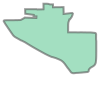

In [13]:
# Extract polygon geometry
campus_polygon = campus_boundary.geometry.iloc[0]
campus_polygon

In [14]:
# Search for everthing tagged as 'building' within the specified boundary
campus_buildings = osm.features_from_polygon(
    campus_polygon,
    tags={"building": True}
)

campus_buildings

geometry  \
element_type osmid                                                         
way          28775431  POLYGON ((-105.26585 40.00596, -105.26585 40.0...   
             28775448  POLYGON ((-105.26486 40.00597, -105.26469 40.0...   
             28775533  POLYGON ((-105.26486 40.00654, -105.26481 40.0...   
             28775536  POLYGON ((-105.26461 40.00653, -105.26441 40.0...   
             28775541  POLYGON ((-105.26530 40.00707, -105.26515 40.0...   
...                                                                  ...   
relation     9826677   POLYGON ((-105.26199 40.00749, -105.26199 40.0...   
             11964909  POLYGON ((-105.26163 40.00346, -105.26129 40.0...   
             12097289  POLYGON ((-105.26285 40.00283, -105.26285 40.0...   
             12098405  POLYGON ((-105.26289 40.00134, -105.26289 40.0...   
             18555106  MULTIPOLYGON (((-105.26781 40.00893, -105.2678...   

                      access addr:city addr:housenumber addr:postcode  \
element_type osmid                                                      
way          28775431    NaN   Boulder             2200           NaN   
             28775448    NaN   Boulder             1001           NaN   
             28775533    NaN   Boulder             1015           NaN   
             28775536    NaN   Boulder             2370           NaN   
             28775541    NaN   Boulder             2350           NaN   
...                      ...       ...              ...           ...   
relation     9826677     NaN   Boulder             1095           NaN   
             11964909    NaN   Boulder            25890         80310   
             12097289    NaN   Boulder             2480           NaN   
             12098405    NaN   Boulder             2450           NaN   
             18555106    NaN   Boulder             2085           NaN   

                      addr:state           addr:street  \
element_type osmid                                       
way          28775431         CO           Baker Drive   
             28775448         CO       Cockerell Drive   
             28775533         CO       Cockerell Drive   
             28775536         CO           Libby Drive   
             28775541         CO           Libby Drive   
...                          ...                   ...   
relation     9826677         NaN          Regent Drive   
             11964909         CO   Kitterege Loop Road   
             12097289        NaN  Kittredge Loop Drive   
             12098405         CO  Kittredge Loop Drive   
             18555106        NaN       Colorado Avenue   

                                                             description  \
element_type osmid                                                         
way          28775431  Residence hall with a new food court; home of ...   
             28775448  Residence hall with buffet apartments, for sen...   
             28775533                                                NaN   
             28775536                                                NaN   
             28775541                                                NaN   
...                                                                  ...   
relation     9826677   State-of-the-art research and learning laborat...   
             11964909                                                NaN   
             12097289                                                NaN   
             12098405                                                NaN   
             18555106  Athletics and events stadium, expanded with sk...   

                      website amenity  ... covered bench location  \
element_type osmid                     ...                          
way          28775431     NaN     NaN  ...     NaN   NaN      NaN   
             28775448     NaN     NaN  ...     NaN   NaN      NaN   
             28775533     NaN     NaN  ...     NaN   NaN      NaN   
             28775536     NaN     Na

In [18]:
# Search for everthing tagged as 'building' within the specified boundary
campus_water = osm.features_from_polygon(
    campus_polygon,
    tags={"natural":"water",
        "waterway": True,
        "water":True}
)

campus_water

nodes  \
element_type osmid                                                          
way          46197729   [589040165, 2496839092, 589040178, 589040176, ...   
             46938874   [599116490, 599116491, 599116492, 599116493, 5...   
             46938875   [599116499, 4753724662, 599116500, 599116501, ...   
             46938882   [599116565, 599116566, 599116567, 599116568, 5...   
             61758946   [434098986, 434098987, 434098988, 434098989, 4...   
             194217260  [2047352879, 2047352903, 2047352859, 204735286...   
             482560081                           [4753724705, 4753724706]   
             888538283                           [8260987529, 8260987530]   

                         ele gnis:feature_id           name natural  \
element_type osmid                                                    
way          46197729   1649          178656   Varsity Lake   water   
             46938874    NaN             NaN            NaN   water   
             46938875    NaN             NaN            NaN   water   
             46938882    NaN             NaN      Kitt Pond   water   
             61758946    NaN             NaN  Boulder Creek     NaN   
             194217260   NaN             NaN            NaN     NaN   
             482560081   NaN             NaN            NaN     NaN   
             888538283   NaN             NaN            NaN     NaN   

                       short_name      water  \
element_type osmid                             
way          46197729        W-VL  reservoir   
             46938874         NaN        NaN   
             46938875         NaN        NaN   
             46938882         NaN       pond   
             61758946         NaN        NaN   
             194217260        NaN        NaN   
             482560081        NaN        NaN   
             888538283        NaN        NaN   

                                                                 geometry  \
element_type osmid                                                          
way          46197729   POLYGON ((-105.27394 40.00972, -105.27393 40.0...   
             46938874   POLYGON ((-105.25921 40.00682, -105.25919 40.0...   
             46938875   POLYGON ((-105.25954 40.00786, -105.25957 40.0...   
             46938882   POLYGON ((-105.26259 40.00270, -105.26258 40.0...   
             61758946   LINESTRING (-105.29443 40.01364, -105.29417 40...   
             194217260  LINESTRING (-105.26105 40.00291, -105.26101 40...   
             482560081  LINESTRING (-105.25917 40.00785, -105.25913 40...   
             888538283  LINESTRING (-105.26306 40.00090, -105.26300 40...   

                                                              description  \
element_type osmid                                                          
way          46197729                                                 NaN   
             46938874                                                 NaN   
             46938875                                                 NaN   
             46938882   No fishing allowed, frequented by canadian gee...   
             61758946                                                 NaN   
             194217260                                                NaN   
             482560081                                                NaN   
             888538283                                                NaN   

                       intermittent waterway source     usage  
element_type osmid                                             
way          46197729           NaN      NaN    NaN       NaN  
             46938874           NaN      NaN    NaN       NaN  
             46938875           NaN      NaN    NaN       NaN  
             46938882            no      NaN    NaN       NaN  
             61758946            no   stream    NaN       NaN  
             194217260          NaN    drain   bing       NaN  
             482560081          yes    canal    NaN

<Axes: >

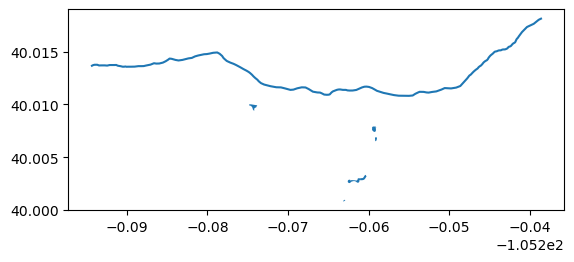

In [19]:
campus_water.plot()

In [22]:
# Splitting water into lines and polygons for easier plotting 
water_polygons = campus_water[
    campus_water.geometry.geom_type.isin(
        ["Polygon", "MultiPolygon"])]

water_polygons


water_lines = campus_water[
    campus_water.geometry.geom_type.isin(
        ["LineString", "MultiLineString"])]

water_lines

nodes  \
element_type osmid                                                          
way          61758946   [434098986, 434098987, 434098988, 434098989, 4...   
             194217260  [2047352879, 2047352903, 2047352859, 204735286...   
             482560081                           [4753724705, 4753724706]   
             888538283                           [8260987529, 8260987530]   

                        ele gnis:feature_id           name natural short_name  \
element_type osmid                                                              
way          61758946   NaN             NaN  Boulder Creek     NaN        NaN   
             194217260  NaN             NaN            NaN     NaN        NaN   
             482560081  NaN             NaN            NaN     NaN        NaN   
             888538283  NaN             NaN            NaN     NaN        NaN   

                       water  \
element_type osmid             
way          61758946    NaN   
             194217260   NaN   
             482560081   NaN   
             888538283   NaN   

                                                                 geometry  \
element_type osmid                                                          
way          61758946   LINESTRING (-105.29443 40.01364, -105.29417 40...   
             194217260  LINESTRING (-105.26105 40.00291, -105.26101 40...   
             482560081  LINESTRING (-105.25917 40.00785, -105.25913 40...   
             888538283  LINESTRING (-105.26306 40.00090, -105.26300 40...   

                       description intermittent waterway source     usage  
element_type osmid                                                         
way          61758946          NaN           no   stream    NaN       NaN  
             194217260         NaN          NaN    drain   bing       NaN  
             482560081         NaN          yes    canal    NaN  spillway  
             888538283         NaN          NaN    drain    NaN       NaN

In [26]:
# Clip water lines to campus boundary
water_lines_clipped = gpd.clip(
    water_lines,
    campus_boundary
)

water_lines_clipped

nodes  \
element_type osmid                                                          
way          888538283                           [8260987529, 8260987530]   
             194217260  [2047352879, 2047352903, 2047352859, 204735286...   
             482560081                           [4753724705, 4753724706]   
             61758946   [434098986, 434098987, 434098988, 434098989, 4...   

                        ele gnis:feature_id           name natural short_name  \
element_type osmid                                                              
way          888538283  NaN             NaN            NaN     NaN        NaN   
             194217260  NaN             NaN            NaN     NaN        NaN   
             482560081  NaN             NaN            NaN     NaN        NaN   
             61758946   NaN             NaN  Boulder Creek     NaN        NaN   

                       water  \
element_type osmid             
way          888538283   NaN   
             194217260   NaN   
             482560081   NaN   
             61758946    NaN   

                                                                 geometry  \
element_type osmid                                                          
way          888538283  LINESTRING (-105.26306 40.00090, -105.26300 40...   
             194217260  LINESTRING (-105.26105 40.00291, -105.26101 40...   
             482560081  LINESTRING (-105.25917 40.00785, -105.25913 40...   
             61758946   LINESTRING (-105.27247 40.01180, -105.27216 40...   

                       description intermittent waterway source     usage  
element_type osmid                                                         
way          888538283         NaN          NaN    drain    NaN       NaN  
             194217260         NaN          NaN    drain   bing       NaN  
             482560081         NaN          yes    canal    NaN  spillway  
             61758946          NaN           no   stream    NaN       NaN

In [27]:
# Create an interactive map of the boundary and buildings
building_layer = campus_buildings.hvplot(
    geo=True,
    #tiles="EsriImagery",
    line_color="black",
    fill_color="yellow",
    alpha=0.9,
    width=850,
    height=650
)

boundary_layer = campus_boundary.hvplot(
    geo=True,
    line_color="yellow",
    fill_color="yellow",
    fill_alpha=0.2,
    line_width=4
)

water_boundary_layer = water_polygons.hvplot(
    geo=True,
    line_color="blue",
    line_width=2,
    fill_color="blue",
    fill_alpha=0.2
)

water_line_layer = water_lines_clipped.hvplot(
    geo=True,
    line_color="blue",
    line_width=2
)
building_layer * boundary_layer * water_boundary_layer * water_line_layer

:Overlay
   .Polygons.I   :Polygons   [Longitude,Latitude]
   .Polygons.II  :Polygons   [Longitude,Latitude]
   .Polygons.III :Polygons   [Longitude,Latitude]
   .Path.I       :Path   [Longitude,Latitude]

Why Use an OSM Object ID?

**Advantages:**

* avoids geocoding problems
* uses an exact OSM boundary
* highly reproducible
* common in GIS and research workflows

This workflow is especially useful when:

* place names fail
* campuses have multiple boundaries
* you want consistent study areas across analyses

# Now it is your turn
You have seen 4 different approaches to querying OSM for information about CU Boulder through seaching by address, point, place, and polygon. Now it is your turn to try this workflow out for a campus you are intersted in. Try adding buildings, highways, waterways, parks, etc. if you are feeling creative. Try adding more code and markdown cells below to get started creating your campus maps, and have some fun!